In [1]:
# 06 -- like 05, but I'm adding in the per-interpreter variability


In [2]:
# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Landsat_OLI",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.02,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.03,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.01,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 3,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.10,
                },
            },
        },

        {
            "name": "Sentinel2_MSI",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 8.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 2.0,
                "beta": 5.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.3,
            },
        },
    },
}

In [3]:
train_experiment_config = {
    "n_stacks": 10,
    "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
    "patch_selection_seed": 123,

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 200,
    "sampling_seed": 42,
}

In [4]:
# set up the interpreters

# new to 06 -- the interpreter stuff
from interpreter_agent import InterpreterAgent, InterpreterGroup

model_building_interp_cfg = {
    "interpreter_id": "interpreterBuildingModel",
    "consistency_std_pct": 5.0,
    "bias_std_pct": 0.0,
    "confidence_std": 0.3,
    "seed": 101,
}
model_interp1 = InterpreterAgent(**model_building_interp_cfg)

validation_interp1_cfg = {
    "interpreter_id": "validation_interp1",
    "consistency_std_pct": 5.0,
    "bias_std_pct": 2.0,
    "confidence_std": 0.3,
    "seed": 101,
}
val_interp1 = InterpreterAgent(**validation_interp1_cfg)


# usage later:  
# train_collection.buildModel(
#     sensor_names=None,
#     n_strata=5,
#     samples_per_stratum=200,
#     sampling_seed=123,
#     interpreter_agent=expert_1,
# )

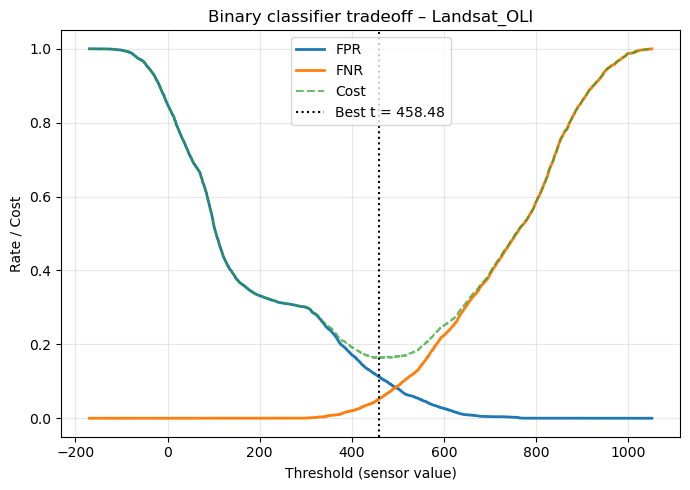

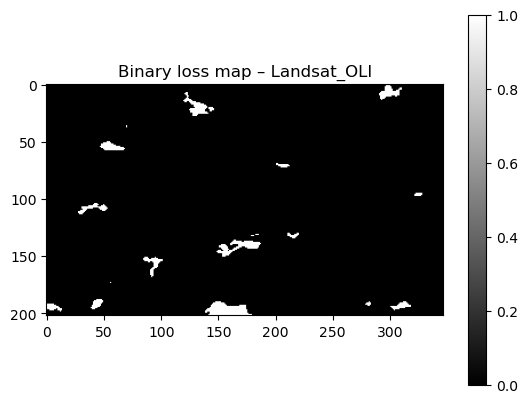

In [5]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection



train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=train_experiment_config,
)

#adding in the interpreter agent

train_collection.buildModel(
                    sensor_names=None,
                    n_strata=5,
                    samples_per_stratum=200,
                    sampling_seed=123,
                    interpreter_agent=model_interp1,
                            )   #continuous logistic probability






train_collection.buildBinaryClassifier()   # classic binary loss
# Visualize tradeoff curves
train_collection.plotBinaryCurves("Landsat_OLI")

# Apply the classifier to all stacks
train_collection.applyBinaryClassifier()

# Look at a binary loss map for one stack/sensor
stack0 = train_collection.stacks[0]
bin_map = stack0.binary_class_by_sensor["Landsat_OLI"]

import matplotlib.pyplot as plt
plt.imshow(bin_map, cmap="gray")
plt.title("Binary loss map – Landsat_OLI")
plt.colorbar()
plt.show()


In [6]:
# next build a validation dataset from a different set of landscapes
#  to do this, we need to make sure that the landscapes are different.  

used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_experiment_config = {
    "n_stacks": 1,   # or however many you want for this second set
 #   "disturbance_seed_base": 20_000,
  #  "use_separate_seeds_per_stack": True,

    "patch_dir": "downloaded_images/",
   # "patch_selection_seed": 456,  # different seed from training if you want

    "sensor_name_for_strat": "Landsat_OLI",
    "n_strata": 5,
    "samples_per_stratum": 200,
#    "sampling_seed": 99,
}

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=val_experiment_config,
    exclude_tif_paths=used_tifs,
)



      stack_id  stack_index  sensor_name  row  col  map_class  \
0  DL_48112003            0  Landsat_OLI   15   98          0   
1  DL_48112003            0  Landsat_OLI  164   11          0   
2  DL_48112003            0  Landsat_OLI  165  167          0   
3  DL_48112003            0  Landsat_OLI  185  182          0   
4  DL_48112003            0  Landsat_OLI  103  209          0   

   interpreter_prob  ref_class  disturbed  final_cover  
0         38.530082          0      False      90.8091  
1         42.267425          0      False      96.7242  
2         37.182487          0      False      94.8100  
3         41.592119          0      False      90.0475  
4         43.032445          0      False      69.4722  
200 samples total
n_ij:
[[100   0]
 [ 34  66]]
n_i: [100 100] n_total: 200

================ CONFUSION MATRIX (Reference vs Classified) ================

                Predicted
              |   0     |    1   
        --------------------------
Reference 0  |    

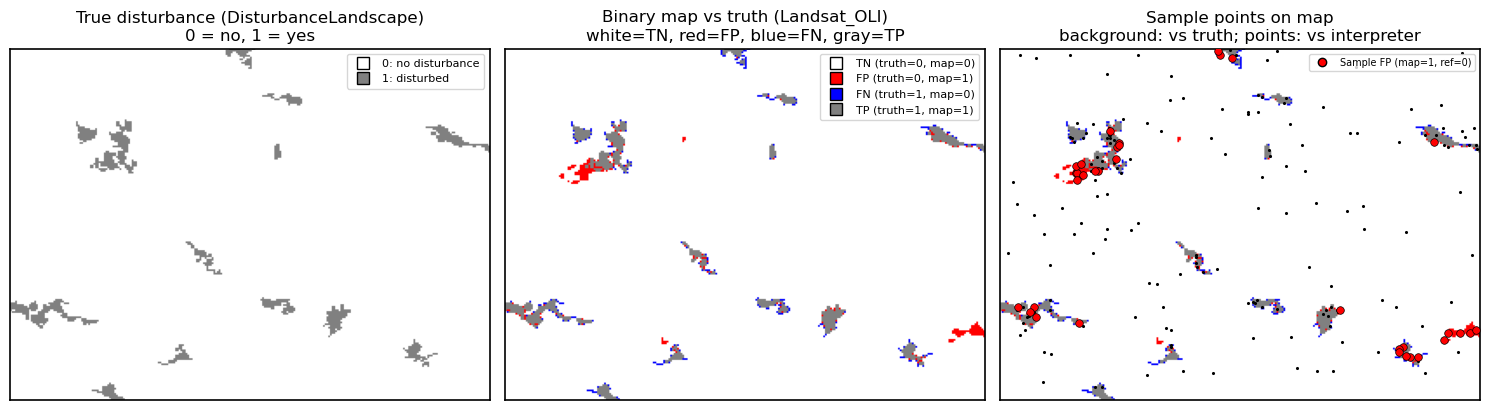

In [7]:
#  Now apply the models from the training set, and apply the classifier. 
#  then sample and validate

# 1. Load binary models from training and apply to val_collection
val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier()

# 2. Draw stratified sample from binary map
samples = val_collection.binary_stratified_sample(
    sensor_name="Landsat_OLI",              # or your sensor name
    n_samples_per_class={0: 100, 1: 100},   # configure as you wish
    sampling_seed=123,
    include_truth=True,
    interpreter_agent = val_interp1,   # this was defined in an earlier block along with the expert one. 
)

print(samples.head())
print(len(samples), "samples total")

# 3. Quick confusion matrix check
cm = val_collection.binary_confusion_from_samples(samples)
print("n_ij:")
print(cm["n_ij"])
print("n_i:", cm["n_i"], "n_total:", cm["n_total"])
n_ij = cm["n_ij"]

n00, n01 = n_ij[0, 0], n_ij[0, 1]
n10, n11 = n_ij[1, 0], n_ij[1, 1]

TN = n00  # map=0, ref=0
FP = n10  # map=1, ref=0
FN = n01  # map=0, ref=1
TP = n11  # map=1, ref=1

print("\n================ CONFUSION MATRIX (Reference vs Classified) ================\n")
print("                Predicted")
print("              |   0     |    1   ")
print("        --------------------------")
print(f"Reference 0  |  {n00:5d} | {n01:5d}")
print(f"Reference 1  |  {n10:5d} | {n11:5d}")
print("\nInterpretation:")
print(f"  True Negatives (TN): {TN} -- correctly predicted no-loss")
print(f"  False Positives (FP): {FP} -- predicted disturbance where interpreter said none")
print(f"  False Negatives (FN): {FN} -- missed disturbance according to interpreter")
print(f"  True Positives (TP): {TP} -- correctly predicted disturbance\n")

print("Derived metrics:")
total = n00 + n01 + n10 + n11
acc = (TP + TN) / total if total > 0 else float('nan')
sens = TP / (TP + FN) if (TP + FN) > 0 else float('nan')   # recall
spec = TN / (TN + FP) if (TN + FP) > 0 else float('nan')   # specificity
ppv = TP / (TP + FP) if (TP + FP) > 0 else float('nan')    # precision
npv = TN / (TN + FN) if (TN + FN) > 0 else float('nan')

print(f"  Overall Accuracy:     {acc:0.3f}")
print(f"  Sensitivity (TPR):    {sens:0.3f}  (recall)")
print(f"  Specificity (TNR):    {spec:0.3f}")
print(f"  Precision (PPV):      {ppv:0.3f}")
print(f"  Neg. Predictive Val.: {npv:0.3f}")
print("==========================================================================\n")

# 4. Olofsson error-adjusted area estimates
ol = val_collection.olofsson_area_estimates(
    samples,
    sensor_name="Landsat_OLI",
    disturbed_class=1,
    alpha=0.05,
)

print("Map area proportions W (map class 0,1):", ol["W"])
print("Adjusted area proportions P̂ (ref class 0,1):", ol["P_hat"])
print("SE(P̂):", ol["SE"])
print("95% CI (class 0,1):")
print("  lower:", ol["CI"]["lower"])
print("  upper:", ol["CI"]["upper"])
print("True disturbed proportion:", ol["true_disturbed_prop"])
print("Is true disturbed within CI for class 1?", ol["disturbed_in_CI"])

# visualization stuff
val_collection.debug_plot_truth_vs_binary(
    stack_index=0,
    sensor_name="Landsat_OLI",
    samples=samples,
)


